In [13]:
from src.DataFolder import DataFolder
from src.NeuralSignal import NeuralSignal
from src.runtime_logger import logger_setup

import yaml
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

data_path = "/home/miranjo/phasic_tonic/data/processed/combined"
config_path = "/home/miranjo/phasic_tonic/configs/test.yaml"

## Setup

### Load the config file

In [14]:
with open(config_path, 'r') as f:
    args = yaml.safe_load(f)

fs                  = args.pop("fs")
f_theta             = (args.pop("f_theta_lower"), args.pop("f_theta_upper"))
f_lowpass           = args.pop("f_lowpass")
lowpass_length      = args.pop("lowpass_length")
bandpass_length     = args.pop("bandpass_length")
threshold_bycycle   = args.pop("threshold_bycycle")
threshold_episode   = args.pop("threshold_episode")

# Start logger
logger_setup()

<Logger runtime (DEBUG)>

### Load the dataset

In [15]:
remFolder = DataFolder(data_path)

# Segmenting REM sleep into phasic and tonic episodes.

## Direct approach

We use the cycle-by-cycle approach to identify phasic and tonic REM sleep substates in rodents.

### Load and preprocess the data

(0.0, 1.5)

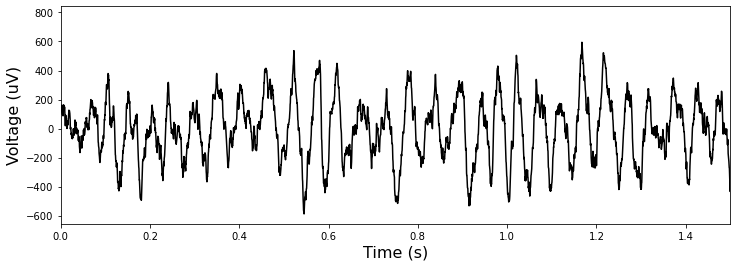

In [38]:
remData = remFolder[4]
arrays = remData["data"]

sig = arrays[0]

times = np.arange(0, len(sig)/fs, 1 / fs)
plt.figure(figsize=(12,4))
plt.xlabel('Time (s)', fontsize=16)
plt.ylabel('Voltage (uV)', fontsize=16)
plt.plot(times, sig, color='k', label='raw')
plt.xlim(0, 1.5)

(0.0, 5.0)

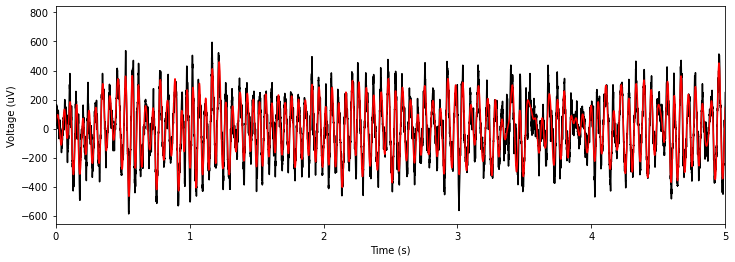

In [39]:
# Apply a Lowpass filter
from neurodsp.filt import filter_signal

sig_low = filter_signal(sig, fs, "lowpass", f_lowpass, n_seconds=lowpass_length, remove_edges=False)
plt.figure(figsize=(12,4))
plt.xlabel('Time (s)')
plt.ylabel('Voltage (uV)')
plt.plot(times, sig, color='k', label='raw')
plt.plot(times, sig_low, color='r', label='lowpass')
plt.xlim(0, 5)

### Segmenting the signal into phasic and tonic episodes

In [40]:
from bycycle.features import compute_features

# Compute cycle-by-cycle features
df = compute_features(sig_low, fs, f_range=f_theta, threshold_kwargs=threshold_bycycle)

# Extract the timestamps and burst detection results
df = df[["sample_last_trough", "sample_next_trough", "is_burst"]]
phasic_df = df[df["is_burst"] == True]
tonic_df = df[df["is_burst"] == False]

In [41]:
phasic_df

,sample_last_trough,sample_next_trough,is_burst
195,58073,58196,True
196,58196,58421,True
197,58421,58652,True
198,58652,58990,True
199,58990,59251,True
200,59251,59606,True
201,59606,59826,True
202,59826,60062,True
203,60062,60293,True
204,60293,60522,True


In [46]:
def get_episodes(df_features, threshold_episode):
    l1 = df_features["sample_last_trough"].to_numpy()
    l2 = df_features["sample_next_trough"].to_numpy()

    # List to store extracted episodes
    episodes = []

    # Assign the start of the first episode
    start = l1[0]
    
    # Initialize the end of the first episode
    end = 0

    for i, l1_i in enumerate(l1):
        print("start:", start)
        print("end:", end)
        print("i:", i)
        print("l1_i", l1_i)
        print("episodes:", episodes)

        diff = l1_i - l2[i - 1]
        print("diff:", diff)

        if (diff) > threshold_episode:
            # Set the end of the current episode
            end = l2[i - 1]
            # Append the current episode to the list
            episodes.append((start, end))
            # Update the start for the next episode
            start = l1_i
    # Set the end of the last episode
    end = l2[-1]
    # Append the last episode to the list
    episodes.append((start, end))
    return episodes
 
threshold_episode = 2500 # If two cycles are within 2500 sampling points, i.e 1 second, then they are connected

# Connect the consecutive cycles to form an episode 
phasic = get_episodes(phasic_df, threshold_episode=threshold_episode)
tonic = get_episodes(tonic_df, threshold_episode=0)
phasic

start: 58073
end: 0
i: 0
l1_i 58073
episodes: []
diff: -2571
start: 58073
end: 0
i: 1
l1_i 58196
episodes: []
diff: 0
start: 58073
end: 0
i: 2
l1_i 58421
episodes: []
diff: 0
start: 58073
end: 0
i: 3
l1_i 58652
episodes: []
diff: 0
start: 58073
end: 0
i: 4
l1_i 58990
episodes: []
diff: 0
start: 58073
end: 0
i: 5
l1_i 59251
episodes: []
diff: 0
start: 58073
end: 0
i: 6
l1_i 59606
episodes: []
diff: 0
start: 58073
end: 0
i: 7
l1_i 59826
episodes: []
diff: 0
start: 58073
end: 0
i: 8
l1_i 60062
episodes: []
diff: 0
start: 58073
end: 0
i: 9
l1_i 60293
episodes: []
diff: 0
start: 58073
end: 0
i: 10
l1_i 60522
episodes: []
diff: 0
start: 102
end: 0
i: 0
l1_i 102
episodes: []
diff: -95866
start: 102
end: 0
i: 1
l1_i 331
episodes: []
diff: 0
start: 102
end: 0
i: 2
l1_i 685
episodes: []
diff: 0
start: 102
end: 0
i: 3
l1_i 945
episodes: []
diff: 0
start: 102
end: 0
i: 4
l1_i 1367
episodes: []
diff: 0
start: 102
end: 0
i: 5
l1_i 1608
episodes: []
diff: 0
start: 102
end: 0
i: 6
l1_i 1884
episodes: 

[(58073, 60644)]

In [46]:
tonic

[(312, 106815), (109012, 171571), (174690, 305456)]

## NeuralSignal approach

We can process the previous steps in an object oriented way.

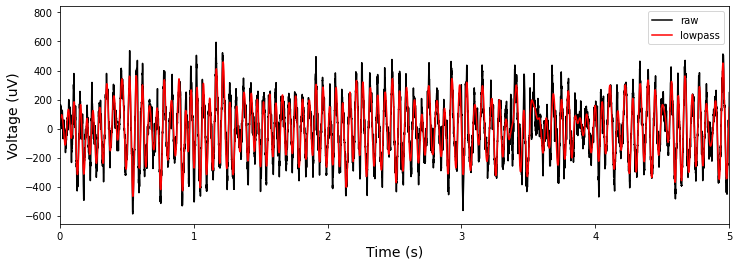

In [36]:
remData = remFolder[4]
arrays = remData["data"]
metadata = remData["metadata"]

theta = NeuralSignal(arrays[0], fs)
theta.filter("lowpass", f_range=f_lowpass, n_seconds=lowpass_length)
theta.plot(xlim=(0,5), figsize=(12,4))

Run the cycle-by-cycle algorithm. We then segment the signal into phasic and tonic episodes.

In [37]:
theta.segment(f_range=f_theta, threshold_episode=threshold_episode, threshold_bycycle=threshold_bycycle)
theta.phasic

[(58073, 60644)]

# Visualizing the data

In [ ]:
import plotly.express as px
import plotly.graph_objects as go

signal = sig_low
t = np.arange(len(signal))/fs
fig = go.Figure(data=go.Scatter(x=t, y=signal, mode='lines', line=dict(color="black")))

fig.update_xaxes(rangeslider_visible=True)
fig.update_layout(title="Rat3 LFP", xaxis_title="Time", yaxis_title="Voltage (uV)")

f = go.FigureWidget(fig)
f